# Loading data

In [160]:
!gdown 1Lw-G0cesnF_LL3PzvfJWG2vY4AuyBXYc

Downloading...
From: https://drive.google.com/uc?id=1Lw-G0cesnF_LL3PzvfJWG2vY4AuyBXYc
To: /content/heart_disease.csv
100% 12.4k/12.4k [00:00<00:00, 23.4MB/s]


In [161]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [162]:
df = pd.read_csv('heart_disease.csv')
df.head()

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


# EDA

In [163]:
df.columns

Index(['Unnamed: 0', 'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
       'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [164]:
df.shape

(303, 15)

In [165]:
df.drop('Unnamed: 0', axis = 1, inplace = True)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [166]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [167]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [168]:
df['target'].value_counts()

,count
target,
1,165
0,138


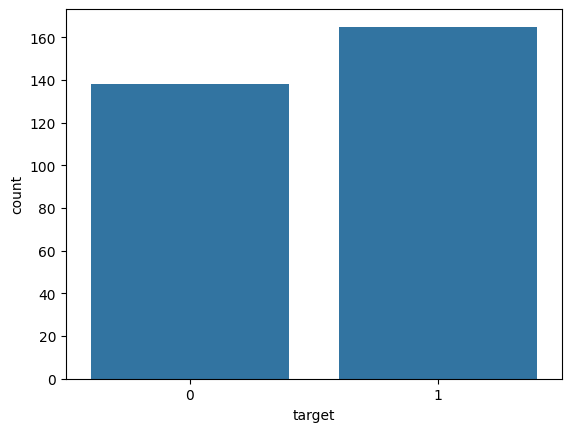

In [169]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='target', data=df)
plt.show()

In [170]:
cols = ['age', 'trestbps',	'chol', 'thalach', 'oldpeak']
for i in cols:

  Q1 = df[i].quantile(0.25)
  Q3 = df[i].quantile(0.75)

  IQR = Q3 - Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  outliers = df[(df[i] < lower) | ([df[i]] > upper)]

  print(f"{i}: {len(outliers)} outliers")
  print("\n")

age: 0 outliers


trestbps: 9 outliers


chol: 5 outliers


thalach: 1 outliers


oldpeak: 5 outliers




Medical data needs outliers. they can be useful information. so we'll keep them

# Preprocessing

In [171]:
X = df.iloc[:,0:13]
y = df.iloc[:,-1]

In [172]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2)
X_train.shape, y_train.shape

((242, 13), (242,))

In [173]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [174]:
X_train

array([[-0.28862757,  0.67663234, -0.93856285, ..., -0.6677359 ,
        -0.73827748, -3.8324517 ],
       [ 1.34843195,  0.67663234,  1.01106985, ..., -0.6677359 ,
        -0.73827748,  1.11836669],
       [-0.72517678, -1.47790748,  1.01106985, ...,  0.94818498,
        -0.73827748, -0.53190611],
       ...,
       [-0.28862757,  0.67663234,  0.0362535 , ...,  0.94818498,
         0.24338818, -0.53190611],
       [ 0.58447084, -1.47790748,  1.01106985, ...,  0.94818498,
         0.24338818, -0.53190611],
       [ 0.36619623,  0.67663234, -0.93856285, ..., -2.28365678,
         2.20671951, -2.1821789 ]])

# Training the model and Analysis

calculate the value of K

method1

In [175]:
np.sqrt(X_train.shape[0])

np.float64(15.556349186104045)

In [176]:
k = 15

In [177]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors= k)

# train our model
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=15)

In [178]:
y_pred = knn.predict(X_test)

In [179]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pred, y_test)

0.8032786885245902

In [180]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[18, 10],
       [ 2, 31]])

In [192]:
from sklearn.metrics import recall_score, precision_score
recall_score(y_test, knn.predict(X_test))

0.9393939393939394

In [191]:
precision_score(y_test, knn.predict(X_test))

0.775

method 2

In [182]:
diction = {}
count = 1

for i in range(1, 50):
  knn = KNeighborsClassifier(n_neighbors =i)
  knn.fit(X_train, y_train)
  diction[count] = accuracy_score(y_test, knn.predict(X_test))
  count = count+1


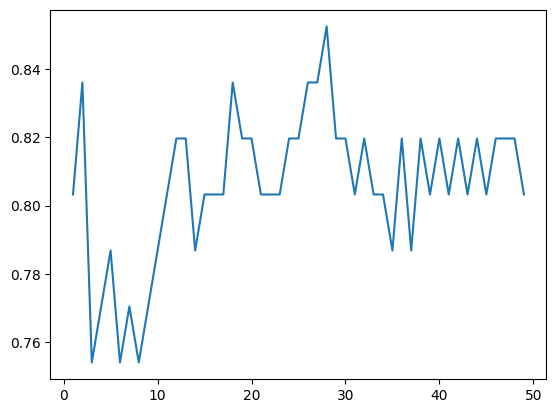

In [183]:
plt.plot(diction.keys(), diction.values())

In [184]:
import operator

diction = sorted(diction.items(), key = operator.itemgetter(1))
diction

[(3, 0.7540983606557377),
 (6, 0.7540983606557377),
 (8, 0.7540983606557377),
 (4, 0.7704918032786885),
 (7, 0.7704918032786885),
 (9, 0.7704918032786885),
 (5, 0.7868852459016393),
 (10, 0.7868852459016393),
 (14, 0.7868852459016393),
 (35, 0.7868852459016393),
 (37, 0.7868852459016393),
 (1, 0.8032786885245902),
 (11, 0.8032786885245902),
 (15, 0.8032786885245902),
 (16, 0.8032786885245902),
 (17, 0.8032786885245902),
 (21, 0.8032786885245902),
 (22, 0.8032786885245902),
 (23, 0.8032786885245902),
 (31, 0.8032786885245902),
 (33, 0.8032786885245902),
 (34, 0.8032786885245902),
 (39, 0.8032786885245902),
 (41, 0.8032786885245902),
 (43, 0.8032786885245902),
 (45, 0.8032786885245902),
 (49, 0.8032786885245902),
 (12, 0.819672131147541),
 (13, 0.819672131147541),
 (19, 0.819672131147541),
 (20, 0.819672131147541),
 (24, 0.819672131147541),
 (25, 0.819672131147541),
 (29, 0.819672131147541),
 (30, 0.819672131147541),
 (32, 0.819672131147541),
 (36, 0.819672131147541),
 (38, 0.81967213114

In [185]:
knn = KNeighborsClassifier(n_neighbors = 24)
knn.fit(X_train, y_train)


accuracy_score(knn.predict(X_test), y_test)

0.819672131147541

effect of k on training error rate and validation error rate

In [186]:
error_train =[]
error_test = []

for i in range(1, 30):
  knn = KNeighborsClassifier(n_neighbors= i)
  knn.fit(X_train, y_train)
  x = confusion_matrix(y_train, knn.predict(X_train))
  y = confusion_matrix(y_test, knn.predict(X_test))
  error_train.append((x[0][1] + x[1][0])/x.sum())
  error_test.append((y[0][1] + y[1][0])/ x.sum())


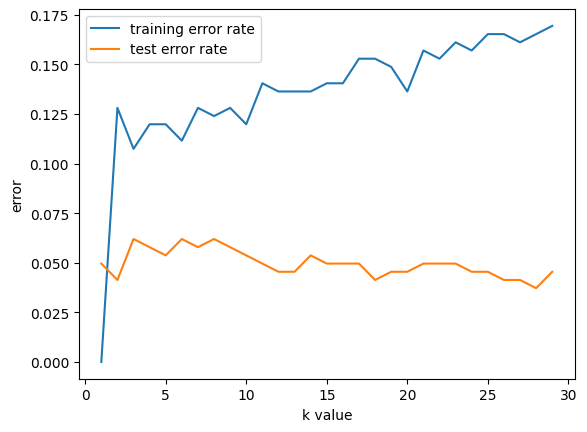

In [187]:
plt.plot(range(1,30), error_train, label = 'training error rate')
plt.plot(range(1,30), error_test, label = 'test error rate')
plt.xlabel('k value')
plt.ylabel('error')
plt.legend()
plt.show()

In [188]:
print("Training accuracy:", accuracy_score(knn.predict(X_train), y_train))
print("Testing accuracy:", accuracy_score(knn.predict(X_test), y_test))

Training accuracy: 0.8305785123966942
Testing accuracy: 0.819672131147541


In [189]:

recall_score(y_test, knn.predict(X_test))


0.9393939393939394

In [190]:
precision_score(y_test, knn.predict(X_test))

0.775

Of all the people who actually have heart disease, my model correctly identifies 96.8%

Of all the people my model predicted as having heart disease, 81.5% actually have it.

**The KNN model achieved approximately 87% accuracy, with 96.88% recall and 81.58% precision. The model is particularly effective at identifying positive heart-disease cases, while producing some false positives.**

We also see that using Method 1 out accuracy score, recall score and precision score were low than when using Method 2.